# 05 - Fair Subset (1M-Row Common Training Budget)

**Goal:** Produce one frozen index artifact defining the shared training budget that every model in the benchmark must use. Two candidate sampling strategies are computed and compared; the chosen one is saved.

**Approved decisions:**
- Budget: **1,000,000 rows**.
- Temporal order preserved (subset re-sorted by `time_s`).
- 4-way regime balance preserved: `(methane>0, ethylene>0)` bin proportions match the full dataset under stratified sampling.
- Subset applies to **training windows only** - validation slices stay full.
- Single global subset artifact: `data/subsets/fair_subset_indices.parquet`.
- Downstream: 06 baselines will refit per-fold scalers on `train_range ∩ subset` (strict fairness).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

DATA_PATH    = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH  = Path('../results/tables/validation_splits.parquet')
SUBSET_DIR   = Path('../data/subsets')
FIG_DIR      = Path('../results/figures')
MEMO_PATH    = Path('../results/memos/05_fair_subset.md')

for d in (SUBSET_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

BUDGET          = 1_000_000
SUBSET_STRATEGY = 'stratified'   # 'stratified' or 'chronological'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data & Frozen Splits

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)

n_rows = len(df)
print(f'Dataset rows: {n_rows:,}')
print(f'Budget:       {BUDGET:,} ({BUDGET / n_rows:.1%} of dataset)')

# Build 4-way regime bin: 0=(0,0), 1=(0,1), 2=(1,0), 3=(1,1)
m_pos = (df['methane_ppm']  > 0).to_numpy()
e_pos = (df['ethylene_ppm'] > 0).to_numpy()
bin_id = (m_pos.astype(np.int8) << 1) | e_pos.astype(np.int8)

bin_names = {0: '00 (both 0)', 1: '01 (eth only)', 2: '10 (meth only)', 3: '11 (both)'}
full_counts = pd.Series(bin_id).value_counts().reindex([0, 1, 2, 3], fill_value=0)
full_props  = (full_counts / full_counts.sum()).round(4)
print()
print('Full dataset regime balance:')
for b in range(4):
    print(f'  {bin_names[b]:>20}: n={int(full_counts[b]):>10,}  p={float(full_props[b]):.4f}')

Dataset rows: 4,178,504
Budget:       1,000,000 (23.9% of dataset)

Full dataset regime balance:
           00 (both 0): n= 1,374,390  p=0.3289
         01 (eth only): n=   954,362  p=0.2284
        10 (meth only): n= 1,001,154  p=0.2396
             11 (both): n=   848,598  p=0.2031


## 2. Strategy A - Chronological Downsampling

Evenly spaced row indices across the full timeline (uses `np.linspace` then unique cast to int). Temporal order trivially preserved.

In [3]:
idx_A = np.unique(np.linspace(0, n_rows - 1, BUDGET).astype(np.int64))
# Top up to exact BUDGET if rounding produced duplicates.
if len(idx_A) < BUDGET:
    extra = np.setdiff1d(np.arange(n_rows), idx_A, assume_unique=True)
    idx_A = np.sort(np.concatenate([idx_A, extra[: BUDGET - len(idx_A)]]))
assert len(idx_A) == BUDGET
assert (np.diff(idx_A) >= 0).all(), 'Chronological subset not monotonic'
print(f'Strategy A (chronological): n={len(idx_A):,}')

Strategy A (chronological): n=1,000,000


## 3. Strategy B - Target-Bin Stratified Sampling

Allocate budget proportional to each bin's share of the full dataset, sample without replacement inside each bin, then re-sort the chosen indices to restore temporal order.

In [4]:
prop  = (full_counts / full_counts.sum()).to_numpy()
alloc = np.floor(prop * BUDGET).astype(np.int64)
# Distribute leftover rows to the bins with the largest fractional remainder.
frac      = (prop * BUDGET) - alloc
remainder = BUDGET - alloc.sum()
for b in np.argsort(-frac)[:remainder]:
    alloc[b] += 1
assert alloc.sum() == BUDGET

picked = []
for b in range(4):
    rows = np.flatnonzero(bin_id == b)
    take = alloc[b]
    if take == 0:
        continue
    chosen = rows if take >= len(rows) else rng.choice(rows, size=take, replace=False)
    picked.append(chosen)

idx_B = np.sort(np.concatenate(picked))
assert len(idx_B) == BUDGET
assert (np.diff(idx_B) >= 0).all(), 'Stratified subset not monotonic after sort'

print(f'Strategy B (stratified): n={len(idx_B):,}')
print('Per-bin allocation:')
for b in range(4):
    actual = int((bin_id[idx_B] == b).sum())
    print(f'  {bin_names[b]:>20}: target={int(alloc[b]):>8,}  actual={actual:>8,}')

Strategy B (stratified): n=1,000,000
Per-bin allocation:
           00 (both 0): target= 328,919  actual= 328,919
         01 (eth only): target= 228,398  actual= 228,398
        10 (meth only): target= 239,596  actual= 239,596
             11 (both): target= 203,087  actual= 203,087


## 4. Compare Strategies

In [5]:
def summarize(name, idx):
    rec = {'strategy': name, 'n_rows': int(len(idx))}
    for b in range(4):
        rec[f'bin_{b}_pct'] = round(float((bin_id[idx] == b).mean()), 4)
    rec['time_min'] = float(df[TIME].iloc[idx[0]])
    rec['time_max'] = float(df[TIME].iloc[idx[-1]])
    rec['time_span_pct'] = round(
        (rec['time_max'] - rec['time_min']) /
        (float(df[TIME].iloc[-1]) - float(df[TIME].iloc[0])), 4)
    for fold_id in sorted(splits_df['fold'].unique()):
        tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
        rec[f'fold{int(fold_id)}_in_train'] = int(((idx >= tr['start_idx']) & (idx < tr['end_idx'])).sum())
    return rec

full_rec = summarize('FULL', np.arange(n_rows))
cmp_df = pd.DataFrame([full_rec, summarize('chronological', idx_A), summarize('stratified', idx_B)])
print(cmp_df.to_string(index=False))

     strategy  n_rows  bin_0_pct  bin_1_pct  bin_2_pct  bin_3_pct  time_min  time_max  time_span_pct  fold1_in_train  fold2_in_train  fold3_in_train  fold4_in_train  fold5_in_train
         FULL 4178504     0.3289     0.2284     0.2396     0.2031      0.00  41790.19            1.0         1664421         1634650         1641557         1641541         1671616
chronological 1000000     0.3289     0.2284     0.2396     0.2031      0.00  41790.19            1.0          398330          391204          392857          392854          400051
   stratified 1000000     0.3289     0.2284     0.2396     0.2031      0.01  41790.14            1.0          398670          391532          392782          392275          399678


## 5. Comparison Figure

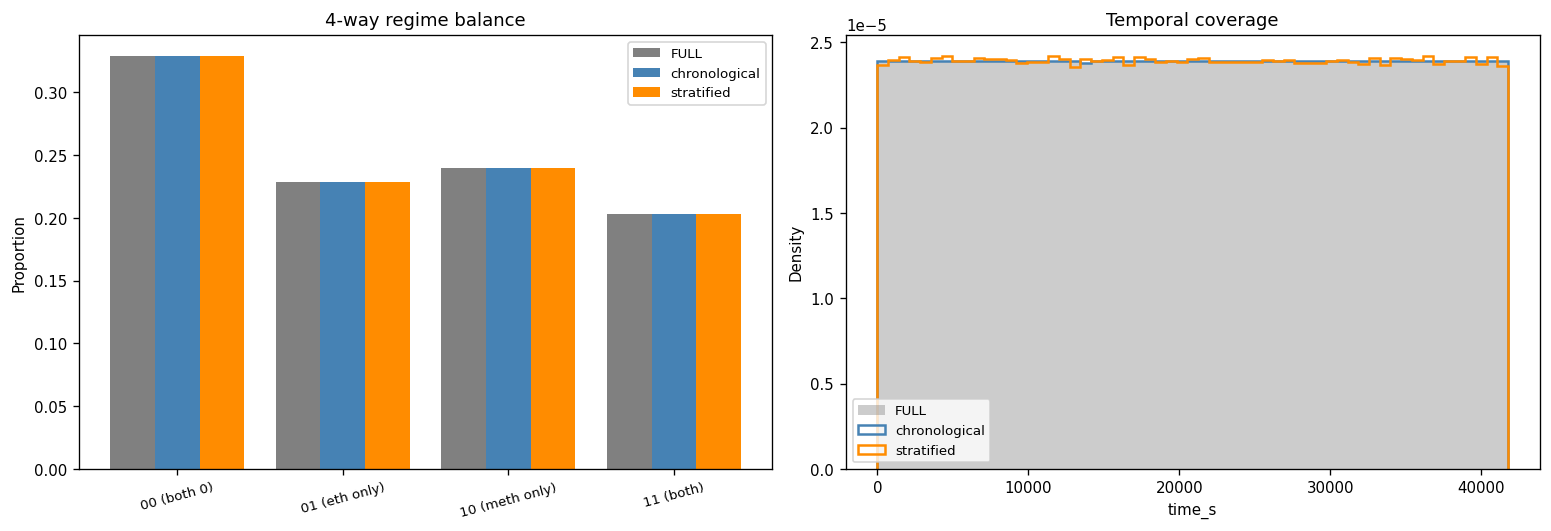

Saved: 05_subset_comparison.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) 4-way regime balance
ax = axes[0]
labels = [bin_names[b] for b in range(4)]
x = np.arange(4)
w = 0.27
full_pct = np.array([(bin_id == b).mean()           for b in range(4)])
A_pct    = np.array([(bin_id[idx_A] == b).mean()    for b in range(4)])
B_pct    = np.array([(bin_id[idx_B] == b).mean()    for b in range(4)])
ax.bar(x - w, full_pct, w, label='FULL',          color='gray')
ax.bar(x,     A_pct,    w, label='chronological', color='steelblue')
ax.bar(x + w, B_pct,    w, label='stratified',    color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, fontsize=8)
ax.set_ylabel('Proportion'); ax.set_title('4-way regime balance')
ax.legend(fontsize=8)

# (b) Temporal coverage density
ax = axes[1]
bins_t = np.linspace(df[TIME].min(), df[TIME].max(), 60)
ax.hist(df[TIME],             bins=bins_t, alpha=0.4, label='FULL',          density=True, color='gray')
ax.hist(df[TIME].iloc[idx_A], bins=bins_t, label='chronological', density=True, color='steelblue',  histtype='step', linewidth=1.5)
ax.hist(df[TIME].iloc[idx_B], bins=bins_t, label='stratified',    density=True, color='darkorange', histtype='step', linewidth=1.5)
ax.set_xlabel('time_s'); ax.set_ylabel('Density'); ax.set_title('Temporal coverage')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_subset_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: 05_subset_comparison.png')

## 6. Select & Save Chosen Subset

`SUBSET_STRATEGY` at the top of the notebook controls the choice. Default is `stratified` (preserves regime balance by construction). Flip to `chronological` and re-run cells 7+ to switch.

In [7]:
chosen_idx   = idx_B if SUBSET_STRATEGY == 'stratified' else idx_A
chosen_label = SUBSET_STRATEGY

# Sanity asserts before persisting.
assert len(chosen_idx) == BUDGET, f'Subset size != budget ({len(chosen_idx)} vs {BUDGET})'
assert (np.diff(chosen_idx) >= 0).all(), 'Subset indices not monotonically increasing (temporal order)'
for fold_id in sorted(splits_df['fold'].unique()):
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    n_in = int(((chosen_idx >= tr['start_idx']) & (chosen_idx < tr['end_idx'])).sum())
    assert n_in > 0, f'Fold {fold_id} train range has zero subset rows'
    print(f'Fold {int(fold_id)} train_window={int(tr["n_rows"]):>10,}  intersect_subset={n_in:>10,}  ({n_in / int(tr["n_rows"]):.1%})')
for b in range(4):
    assert int((bin_id[chosen_idx] == b).sum()) > 0, f'Bin {b} ({bin_names[b]}) empty in chosen subset'

print()
print(f'All sanity checks passed for SUBSET_STRATEGY={chosen_label!r}')

artifact = pd.DataFrame({
    'row_idx':    chosen_idx.astype(np.int64),
    'time_s':     df[TIME].iloc[chosen_idx].to_numpy(),
    'regime_bin': bin_id[chosen_idx].astype(np.int8),
})
out_path = SUBSET_DIR / 'fair_subset_indices.parquet'
artifact.to_parquet(out_path, index=False)
print(f'Saved: {out_path}  ({len(artifact):,} rows)')

Fold 1 train_window= 1,664,421  intersect_subset=   398,670  (24.0%)
Fold 2 train_window= 1,634,650  intersect_subset=   391,532  (24.0%)
Fold 3 train_window= 1,641,557  intersect_subset=   392,782  (23.9%)
Fold 4 train_window= 1,641,541  intersect_subset=   392,275  (23.9%)
Fold 5 train_window= 1,671,616  intersect_subset=   399,678  (23.9%)

All sanity checks passed for SUBSET_STRATEGY='stratified'
Saved: ..\data\subsets\fair_subset_indices.parquet  (1,000,000 rows)


## 7. Save Memo

In [8]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |' for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

summary_rows = []
for label, idx in [('FULL', np.arange(n_rows)), ('chronological', idx_A), ('stratified', idx_B)]:
    summary_rows.append({
        'subset':     label,
        'n_rows':     int(len(idx)),
        'bin_00_pct': round(float((bin_id[idx] == 0).mean()), 4),
        'bin_01_pct': round(float((bin_id[idx] == 1).mean()), 4),
        'bin_10_pct': round(float((bin_id[idx] == 2).mean()), 4),
        'bin_11_pct': round(float((bin_id[idx] == 3).mean()), 4),
    })
summary_md = df_to_md(pd.DataFrame(summary_rows))

fold_rows = []
for fold_id in sorted(splits_df['fold'].unique()):
    tr   = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    n_in = int(((chosen_idx >= tr['start_idx']) & (chosen_idx < tr['end_idx'])).sum())
    fold_rows.append({
        'fold':                int(fold_id),
        'train_window_rows':   int(tr['n_rows']),
        'subset_in_train':     n_in,
        'subset_pct_of_train': round(n_in / int(tr['n_rows']), 4),
    })
fold_md = df_to_md(pd.DataFrame(fold_rows))

lines = [
    '# 05 - Fair Subset (1M-Row Common Training Budget)',
    '',
    '**Date:** 2026-05-20',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Subset artifact:** {(SUBSET_DIR / "fair_subset_indices.parquet").as_posix()}',
    '',
    '---',
    '',
    '## Approved decisions',
    f'- Budget: **{BUDGET:,} rows** (~{BUDGET / n_rows:.1%} of dataset).',
    '- Temporal order preserved (indices sorted by `time_s`).',
    '- 4-way `(methane>0, ethylene>0)` regime balance preserved.',
    '- Applies to **training windows only**; validation slices remain full.',
    '- Single global subset artifact, intersected with each fold train range at model-training time.',
    '- 06 baselines refit per-fold scalers on `train_range ∩ subset` (strict fairness).',
    '',
    f'## Chosen strategy: **{chosen_label}**',
    '',
    'Stratified sampling preserves the 4-way regime balance by construction. Chronological downsampling is reported alongside as a sanity baseline.',
    '',
    '## Strategy comparison (regime balance)',
    '',
    summary_md,
    '',
    '## Per-fold train_window ∩ subset',
    '',
    fold_md,
    '',
    '## Usage (downstream notebooks)',
    '',
    '```python',
    'subset_idx = pd.read_parquet("data/subsets/fair_subset_indices.parquet")["row_idx"].to_numpy()',
    'for fold_id in splits_df["fold"].unique():',
    '    tr = splits_df[(splits_df["fold"] == fold_id) & (splits_df["split"] == "train")].iloc[0]',
    '    va = splits_df[(splits_df["fold"] == fold_id) & (splits_df["split"] == "val")].iloc[0]',
    '    train_idx = subset_idx[(subset_idx >= tr["start_idx"]) & (subset_idx < tr["end_idx"])]',
    '    X_train   = df[SENSORS].iloc[train_idx].to_numpy()',
    '    X_val     = df[SENSORS].iloc[va["start_idx"]:va["end_idx"]].to_numpy()  # full val, NOT subset',
    '```',
    '',
    '## Next step',
    '',
    'Notebook `06_baselines.ipynb` (pending approval): refit per-fold scalers on `train_range ∩ subset`, train baseline models on the fair subset, evaluate on full validation slices.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\05_fair_subset.md
